In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
PATH = 'slooze_challenge./'

sales     = pd.read_csv(PATH + 'SalesFINAL12312016.csv')
purchases = pd.read_csv(PATH + 'PurchasesFINAL12312016.csv')
prices    = pd.read_csv(PATH + '2017PurchasePricesDec.csv')
beg_inv   = pd.read_csv(PATH + 'BegInvFINAL12312016.csv')
end_inv   = pd.read_csv(PATH + 'EndInvFINAL12312016.csv')

sales['SalesDate'] = pd.to_datetime(sales['SalesDate'], format='mixed')

for df in [sales, purchases, prices]:
    str_cols = df.select_dtypes('object').columns
    df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

print('loaded.')

loaded.


In [4]:
product_sales = (
    sales.groupby(['Brand', 'Description'])
    .agg(
        total_revenue = ('SalesDollars', 'sum'),
        total_units   = ('SalesQuantity', 'sum'),
        avg_price     = ('SalesPrice', 'mean'),
        n_transactions= ('SalesDollars', 'count')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print(f'{len(product_sales)} unique products in sales data')
product_sales.head()

7658 unique products in sales data


,Brand,Description,total_revenue,total_units,avg_price,n_transactions
1655,4261,Capt Morgan Spiced Rum,444810.74,20226,21.993047,1969
1309,3545,Ketel One Vodka,357759.17,11883,30.174105,1749
440,1233,Jack Daniels No 7 Black,344712.22,9578,35.990000,1803
2520,8068,Absolut 80 Proof,288135.11,11189,25.776631,1870
1237,3405,Tito's Handmade Vodka,275162.97,9203,29.879714,1750


In [5]:
total_rev = product_sales['total_revenue'].sum()

product_sales['rev_share']  = product_sales['total_revenue'] / total_rev * 100
product_sales['cum_share']  = product_sales['rev_share'].cumsum()

def abc_label(cum_pct):
    if cum_pct <= 70:
        return 'A'
    elif cum_pct <= 90:
        return 'B'
    else:
        return 'C'

product_sales['ABC'] = product_sales['cum_share'].apply(abc_label)

print(product_sales.groupby('ABC').agg(
    products      = ('Brand', 'count'),
    total_revenue = ('total_revenue', 'sum'),
    total_units   = ('total_units', 'sum')
).assign(revenue_pct=lambda x: x['total_revenue'] / total_rev * 100).round(2))

     products  total_revenue  total_units  revenue_pct
ABC                                                   
A         975    23194013.84      1585557        69.99
B        1444     6631138.56       580690        20.01
C        5239     3314222.89       284922        10.00


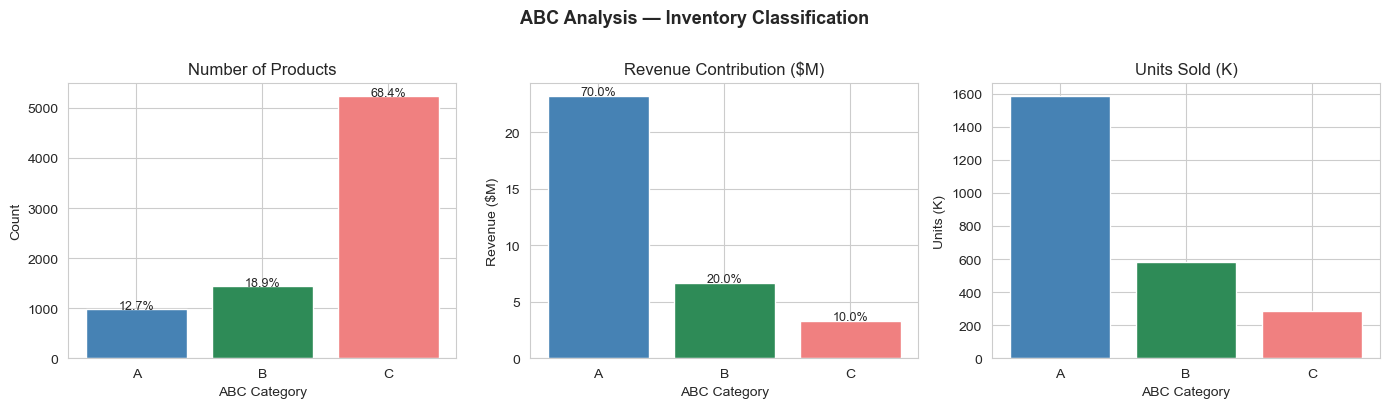

In [6]:
abc_summary = product_sales.groupby('ABC').agg(
    products=('Brand','count'),
    revenue=('total_revenue','sum'),
    units=('total_units','sum')
).reset_index()
abc_summary['rev_pct'] = abc_summary['revenue'] / total_rev * 100
abc_summary['prod_pct'] = abc_summary['products'] / len(product_sales) * 100

colors = {'A': 'steelblue', 'B': 'seagreen', 'C': 'lightcoral'}
c_list = [colors[x] for x in abc_summary['ABC']]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(abc_summary['ABC'], abc_summary['products'], color=c_list)
axes[0].set_title('Number of Products')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(abc_summary['products'], abc_summary['prod_pct'])):
    axes[0].text(i, v + 5, f'{p:.1f}%', ha='center', fontsize=9)

axes[1].bar(abc_summary['ABC'], abc_summary['revenue'] / 1e6, color=c_list)
axes[1].set_title('Revenue Contribution ($M)')
axes[1].set_ylabel('Revenue ($M)')
for i, (v, p) in enumerate(zip(abc_summary['revenue'], abc_summary['rev_pct'])):
    axes[1].text(i, v/1e6 + 0.1, f'{p:.1f}%', ha='center', fontsize=9)

axes[2].bar(abc_summary['ABC'], abc_summary['units'] / 1e3, color=c_list)
axes[2].set_title('Units Sold (K)')
axes[2].set_ylabel('Units (K)')

for ax in axes:
    ax.set_xlabel('ABC Category')

plt.suptitle('ABC Analysis — Inventory Classification', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_abc_summary.png', dpi=150, bbox_inches='tight')
plt.show()

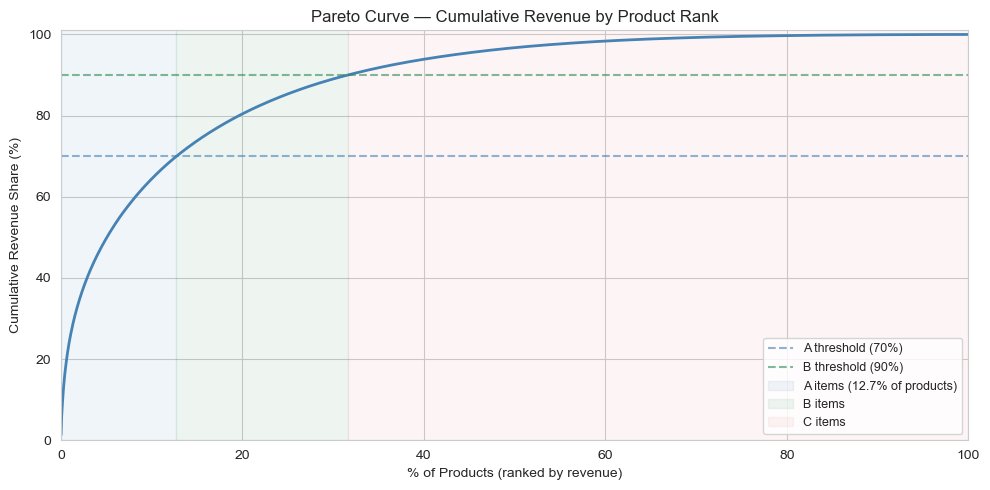

A items: 12.7% of products drive 70% of revenue
B items: 12.7% to 31.6% of products drive next 20%
C items: remaining 68.4% of products drive only 10%


In [7]:
product_sales['product_rank_pct'] = np.arange(1, len(product_sales)+1) / len(product_sales) * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(product_sales['product_rank_pct'], product_sales['cum_share'],
        color='steelblue', linewidth=2)

ax.axhline(70, color='steelblue', linestyle='--', alpha=0.6, label='A threshold (70%)')
ax.axhline(90, color='seagreen',  linestyle='--', alpha=0.6, label='B threshold (90%)')

a_cutoff = product_sales.loc[product_sales['cum_share'] <= 70, 'product_rank_pct'].max()
b_cutoff = product_sales.loc[product_sales['cum_share'] <= 90, 'product_rank_pct'].max()

ax.axvspan(0, a_cutoff,  alpha=0.08, color='steelblue', label=f'A items ({a_cutoff:.1f}% of products)')
ax.axvspan(a_cutoff, b_cutoff, alpha=0.08, color='seagreen', label=f'B items')
ax.axvspan(b_cutoff, 100, alpha=0.08, color='lightcoral', label=f'C items')

ax.set_xlabel('% of Products (ranked by revenue)')
ax.set_ylabel('Cumulative Revenue Share (%)')
ax.set_title('Pareto Curve — Cumulative Revenue by Product Rank')
ax.legend(fontsize=9)
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)

plt.tight_layout()
plt.savefig('plot_pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'A items: {a_cutoff:.1f}% of products drive 70% of revenue')
print(f'B items: {a_cutoff:.1f}% to {b_cutoff:.1f}% of products drive next 20%')
print(f'C items: remaining {100-b_cutoff:.1f}% of products drive only 10%')

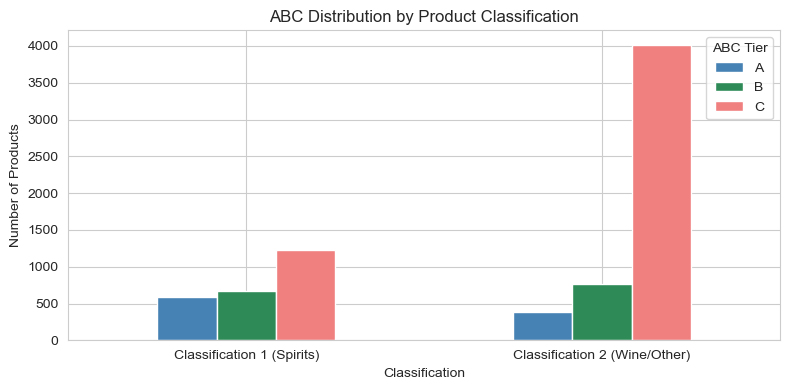

In [8]:
prod_class = sales.groupby('Brand')['Classification'].first().reset_index()
product_sales = product_sales.merge(prod_class, on='Brand', how='left')

class_abc = product_sales.groupby(['Classification','ABC']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(8, 4))
pivot = class_abc.pivot(index='Classification', columns='ABC', values='count').fillna(0)
pivot.plot(kind='bar', ax=ax, color=['steelblue','seagreen','lightcoral'])
ax.set_title('ABC Distribution by Product Classification')
ax.set_ylabel('Number of Products')
ax.set_xticklabels(['Classification 1 (Spirits)', 'Classification 2 (Wine/Other)'], rotation=0)
ax.legend(title='ABC Tier')
plt.tight_layout()
plt.savefig('plot_abc_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

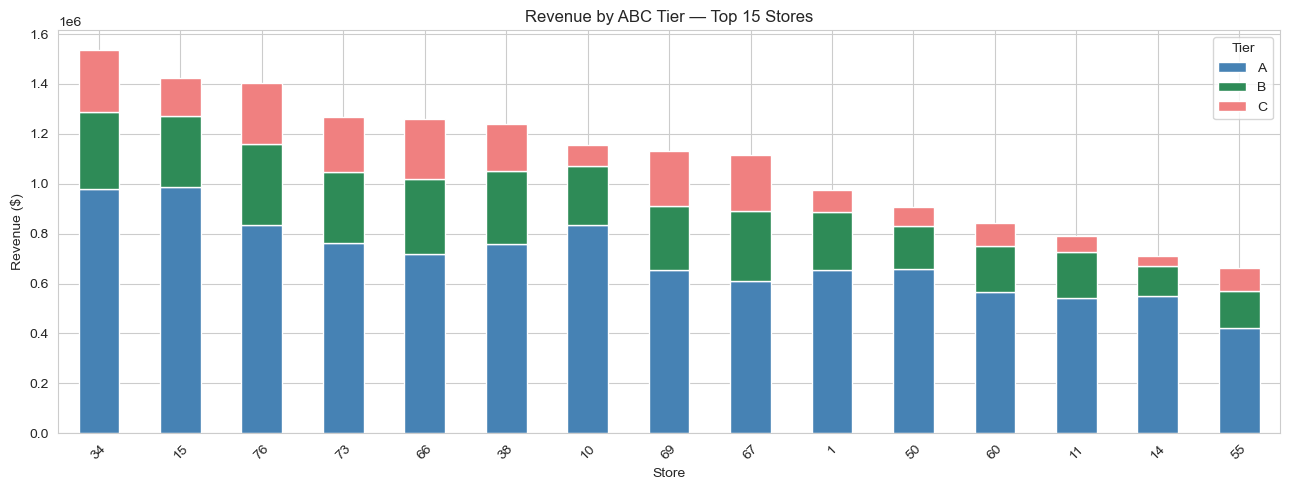

In [9]:
brand_abc = product_sales[['Brand','ABC']]
sales_abc = sales.merge(brand_abc, on='Brand', how='left')

store_abc = (
    sales_abc.groupby(['Store','ABC'])
    .agg(revenue=('SalesDollars','sum'))
    .reset_index()
)

top_store_ids = sales.groupby('Store')['SalesDollars'].sum().nlargest(15).index
store_abc_top = store_abc[store_abc['Store'].isin(top_store_ids)]

pivot_store = store_abc_top.pivot(index='Store', columns='ABC', values='revenue').fillna(0)
pivot_store = pivot_store.loc[top_store_ids]  # keep order

pivot_store.plot(kind='bar', stacked=True, figsize=(13, 5),
                 color={'A':'steelblue','B':'seagreen','C':'lightcoral'})
plt.title('Revenue by ABC Tier — Top 15 Stores')
plt.ylabel('Revenue ($)')
plt.xlabel('Store')
plt.legend(title='Tier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_store_abc_stack.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
c_items = product_sales[product_sales['ABC'] == 'C'].copy()
c_items['rev_per_unit'] = c_items['total_revenue'] / c_items['total_units']

print('High-volume C items (top 10 by units):')
print(c_items.nlargest(10, 'total_units')[['Description','total_revenue','total_units','rev_per_unit']]
      .to_string(index=False))

High-volume C items (top 10 by units):
                 Description  total_revenue  total_units  rev_per_unit
      Russian Standard Vodka        2211.66         2234          0.99
 Dr McGillicuddy's Root Beer        2107.71         2129          0.99
       Burnett's Peach Vodka        2028.51         2049          0.99
           Bacardi Limon Rum        2015.64         2036          0.99
  Maurice's Mentholated Mint        1952.28         1972          0.99
                 Pearl Vodka        1946.34         1966          0.99
        Pearl Cucumber Vodka        1907.73         1927          0.99
Shady Fruit Real Ruby Red Gr        1845.36         1864          0.99
     Dr McGillicuddy's Peach        1804.77         1823          0.99
              Jim Beam Honey        1777.05         1795          0.99


In [11]:
end_stock = end_inv.groupby('Brand').agg(end_stock=('onHand','sum')).reset_index()
product_sales = product_sales.merge(end_stock, on='Brand', how='left')

abc_stock = product_sales.groupby('ABC').agg(
    avg_end_stock = ('end_stock','mean'),
    median_end_stock = ('end_stock','median'),
    products_with_zero_stock = ('end_stock', lambda x: (x == 0).sum())
)
print('Average ending stock by ABC tier:')
print(abc_stock.round(1))

a_zero = product_sales[(product_sales['ABC']=='A') & (product_sales['end_stock']==0)]
print(f'\nA-tier items with zero ending stock: {len(a_zero)}')
if len(a_zero) > 0:
    print(a_zero[['Description','total_revenue','end_stock']].head(10).to_string(index=False))

Average ending stock by ABC tier:
     avg_end_stock  median_end_stock  products_with_zero_stock
ABC                                                           
A           2407.1            1625.0                         0
B            891.3             647.0                         3
C            184.5              81.0                        66

A-tier items with zero ending stock: 0


In [12]:
output = product_sales[['Brand','Description','ABC','total_revenue','total_units',
                         'avg_price','rev_share','cum_share','Classification','end_stock']]
output.to_csv('abc_classified_products.csv', index=False)
print(f'Saved abc_classified_products.csv ({len(output)} rows)')

print('\nFinal ABC breakdown:')
print(output.groupby('ABC').agg(
    n_products=('Brand','count'),
    revenue=('total_revenue','sum'),
    units=('total_units','sum')
).assign(
    rev_pct=lambda x: x['revenue']/x['revenue'].sum()*100
).round(2))

Saved abc_classified_products.csv (7658 rows)

Final ABC breakdown:
     n_products      revenue    units  rev_pct
ABC                                           
A           975  23194013.84  1585557    69.99
B          1444   6631138.56   580690    20.01
C          5239   3314222.89   284922    10.00
